# Introduction
![Gated Models[^gated-note] on HuggingFace](https://i.ibb.co/QjQxFCj8/Screenshot-2025-07-13-at-11-27-47-AM.png){style="float: right; margin: 10px;" width=350 .lightbox #fig-gated}

It's 2025 and major tech giants are locked in an arm race to AGI. Smaller more capable models are coming up every few weeks. 

Gone are the days of figuring out ways to acquire the latest SOTA models' weight, setting up all the dependencies, getting the right CUDA version, AND THEN finding out if the model actual does what it claims to do in the paper.

Argubly now the skill to master is building **model agnostic systems** and being able to quickly reinterate them to the latest models. 

Luckily HuggingFace is where all the open-sourced AI community host and release their latest models. Just to illustrate, here are a few of the more well known names that's active in the community:

* [Apple](https://huggingface.co/organizations/apple/activity/models)
* [Meta](https://huggingface.co/organizations/meta-llama/activity/models)
* [Nvidia](https://huggingface.co/organizations/nvidia/activity/models)
* [Google](https://huggingface.co/organizations/google/activity/models)
* [Microsoft](https://huggingface.co/organizations/microsoft/activity/models)
* [Deepseek](https://huggingface.co/organizations/deepseek-ai/activity/models)
* [Tencent](https://huggingface.co/organizations/tencent/activity/models)
* [Alibaba](https://huggingface.co/organizations/qwen/activity/models)
* [TicTok](https://huggingface.co/organizations/ByteDance-Seed/activity/models)

In this article, we'll look at 3 different ways to quickly access most of the models on the platform:

1. [using the Inference API](#i.-the-inference-api)
2. [calling HuggingFace Space's API](#ii.-huggingface-spaces-api)
3. using the [`transformer`](https://huggingface.co/docs/transformers/index) Library

Method 1 and 2 will be the most straight forward requiring almost zero extra requirements nor expensive hardware.

We will need our `HUGGINGFACEHUB_API_TOKEN` for the first two example, so we will load it from our `secrets.env`[^secrets-note] with [load_dotenv](https://pypi.org/project/python-dotenv/):

[^secrets-note]: your `secrets.env` should look like this:
```yaml
HUGGINGFACEHUB_API_TOKEN=yyyyy
LANGSMITH_API_KEY=zzzzz
OpenRouter_key=xxxxx
```
[^gated-note]: while all models are openly accessible on HuggingFace, some models are gated and requires you to agree to their terms and conditions. This example screen is for access to [`CohereLabs/aya-vision-8b`](https://huggingface.co/CohereLabs/aya-vision-8b)

In [4]:
#| output: false
#| echo: true
#| code-fold: false
# load our HF API Token
from dotenv import load_dotenv
load_dotenv('./secrets.env')

True

# I. The Inference API
since about May 2025, the [serverless inference API](https://colab.research.google.com/github/huggingface/cookbook/blob/main/notebooks/en/enterprise_hub_serverless_inference_api.ipynb) has been replaced by [HF Inference](https://huggingface.co/docs/inference-providers/en/providers/hf-inference) which has *less*[^less-models-note] [available models](https://huggingface.co/models?inference_provider=hf-inference&sort=trending) because they are getting other inference providers involved, which now has billing implication[^hf-billing].

[^less-models-note]: in the long run more models will be available as more providers take on the task of hosting models instead of HuggingFace hosting everything themselves; currently there are about [46k models available](https://huggingface.co/models?inference_provider=all&sort=trending) with inference provider support.
[^hf-billing]: see their blog post on the release [here](https://huggingface.co/blog/inference-providers) for more details, PRO users get $2 inference credit per month and HF inference still seems to be free. Read the [official doc](https://huggingface.co/docs/inference-providers/pricing#hf-inference-cost) on pricing details.

## using `huggingface_hub.InferenceClient()`
For our first example, we are going to test one of the open-sourced model in [text-to-image generation](https://huggingface.co/docs/inference-providers/tasks/text-to-image) as inspired by Simon Willison's [pelicans on bicycle](https://simonwillison.net/2025/Jun/6/six-months-in-llms/) LLM model vibe check. Under the old *serverless inference API* we could simply use the `requests` library calling the endpoint URL with a JSON payload but now with inference providers, the construction of those endpoint URLs are a bit more complicated[^endpoint-notes] but luckily `huggingface_hub.InferenceClient()` helps simplify things:

[^endpoint-notes]: under serverless inference API the endpoint nomenclature is simply `https://api-inference.huggingface.co/models/{model_name}` but now with inference provider, different provider have slightly different endpoint nomenclature. For the example model below, using **Replicate** the endpoint is `https://router.huggingface.co/replicate/v1/models/black-forest-labs/flux-dev-lora/predictions` but using **fal** it is `https://router.huggingface.co/fal-ai/fal-ai/flux-lora`. The [official doc](https://huggingface.co/docs/inference-providers/index#choosing-the-right-approach) actually have a discussion on how to choose the best approach to call these models.

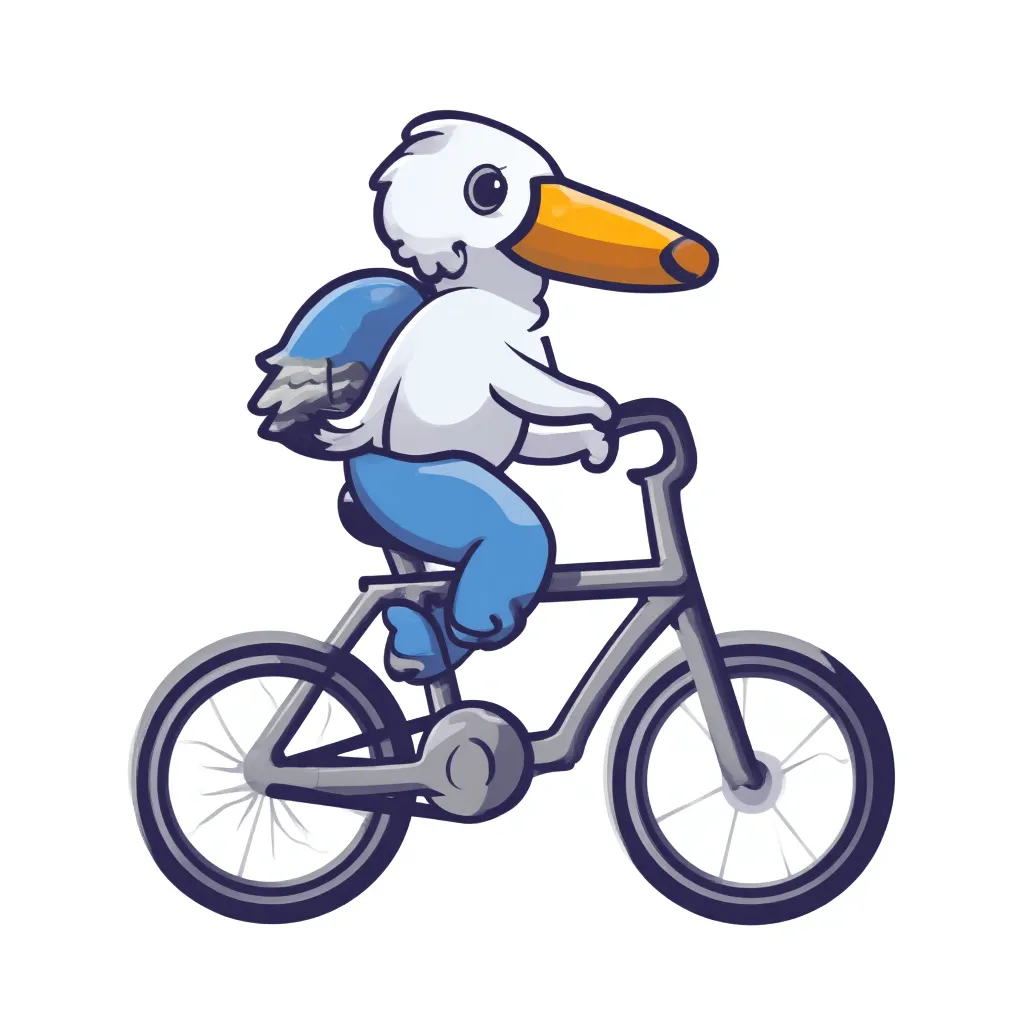

In [11]:
#| code-fold: false
#| fig-cap: Pelican on a Bicycle by [`mujibanget/vector-illustration`](https://huggingface.co/mujibanget/vector-illustration)
#| label: fig-text2image
#| fig-attr: class="preview-image"

import os
from huggingface_hub import InferenceClient

client = InferenceClient(provider = "auto", api_key = os.environ["HUGGINGFACEHUB_API_TOKEN"]) # <1>
image = client.text_to_image( "pelican on a bicycle vector illustration with mujibvector style, isolated in white background", 
                             model = "mujibanget/vector-illustration") # <2>
image

1. for this model you could set `provider` to one of `auto`, `replicate`, or `fal-ai`
2. to learn more about this model click [here](https://huggingface.co/mujibanget/vector-illustration)

## using `OpenAI` compatible endpoint
For [chat completion](https://huggingface.co/docs/inference-providers/tasks/chat-completion) models, we can load up HuggingFace's LLM the same way we call OpenAI's models. So for this example, let's test out one of Roboflow's [Vision Checkup](https://visioncheckup.com) dataset's [OCR prompt](https://visioncheckup.com/assessments/read-a-serial-number/) on Cohere's Aya-Vision-8B[^aya-vision-8b-note]. Before creating your `OpenAI()` client object, you will need to check the [model's page](https://huggingface.co/CohereLabs/aya-vision-8b?inference_api=true&inference_provider=cohere&language=python) for the relavent provider's API and model name[^langchain-note].

[^aya-vision-8b-note]: some models like this one are "gated" meaning that it's publicly accessible but you must first agree to the terms and conditions on HuggingFace prior to access per @fig-gated. This particular model is for **non-commercial use only** and is one of the featured model in this [Multimodal OCR demo](https://huggingface.co/spaces/prithivMLmods/Multimodal-OCR?view=api)
[^langchain-note]: previously using `langchain` you could just
```python
from langchain_openai import ChatOpenAI
chat_model = ChatOpenAI(model="CohereLabs/aya-vision-8b", 
                        base_url = "https://api-inference.huggingface.co/v1/",
                        api_key = os.environ['HUGGINGFACEHUB_API_TOKEN']
                       )
```
which obviously doesn't work anymore but the latest version of [`langchain_huggingface` plugin](https://python.langchain.com/docs/integrations/chat/huggingface/#instantiation) might still provide an easy way to load these models

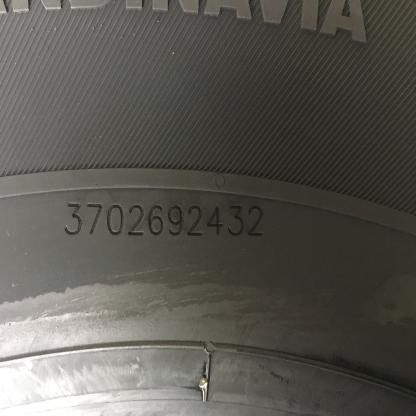

ChatCompletionMessage(content='3702692432', refusal=None, role='assistant', audio=None, function_call=None, tool_calls=None)


In [18]:
#| code-fold: false
#| fig-cap: Example OCR prompt from [VisionCheckup](https://visioncheckup.com/assessments/read-a-serial-number/) - *What is the serial number on the tire?*
#| label: fig-OpenAI-example

from IPython.display import Image, display
from openai import OpenAI

prompt_im_url = "https://visioncheckup.com/images/compressed/tire.jpeg"
client = OpenAI(
    base_url="https://router.huggingface.co/v1", # <1>
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
)

completion = client.chat.completions.create(
    model="CohereLabs/aya-vision-8b", # <2>
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "What is the serial number on the tire? Answer only the serial number."
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": prompt_im_url
                    }
                }
            ]
        }
    ],
)
display(Image(prompt_im_url))
print(completion.choices[0].message)

1. these endpoint routing is still actively being worked on; before July 21, you needed to call `"https://router.huggingface.co/cohere/compatibility/v1"`
2. before July 21, if you want to specify the provider instead of using auto routing you would need to use the model name `"c4ai-aya-vision-8b"` with the custom cohere URL in 1, but now you can just  add a tag to the model name like `"CohereLabs/aya-vision-8b:cohere"`
   
# II. HuggingFace Space's API

But what about models that do not have inference provider? 

For example, [`google/gemma-3n-E4B-it`](https://huggingface.co/google/gemma-3n-E4B-it) isn't deployed by any inference provider as of the writing of this article. However, there are a few spaces running this model and even [one written by the HuggingFace team](https://huggingface.co/spaces/huggingface-projects/gemma-3n-E4B-it).

Spaces were originally created for the community to demo their project. One of the ways to create spaces is with [`gradio`](https://www.gradio.app/docs) which is also created by HuggingFace. What sets it apart from other python apps, like *Streamlit*, is that gradio apps has API and MCP server[^mcp-server-note] built in! **Therefore, you could call *most* spaces built with gradio as an API.**

For this example, we are going to use another prompt from [VisionCheckup](https://visioncheckup.com/assessments/missing-annotation-in-image/) and compare the result against another model that does not have inference provider support: `SmolVLM2`[^smolvlm2-note]

[^mcp-server-note]: yes this makes HuggingFace Space a "MCP App Store" powered by the community [as they call it](https://huggingface.co/blog/gradio-mcp-servers)
[^smolvlm2-note]: using [this space](https://huggingface.co/spaces/Didier/Vision_Language_SmolVLM2?view=api) which demos the model variant  `HuggingFaceTB/SmolVLM2-2.2B-Instruct`

Loaded as API: https://huggingface-projects-gemma-3n-e4b-it.hf.space ✔
Loaded as API: https://didier-vision-language-smolvlm2.hf.space ✔


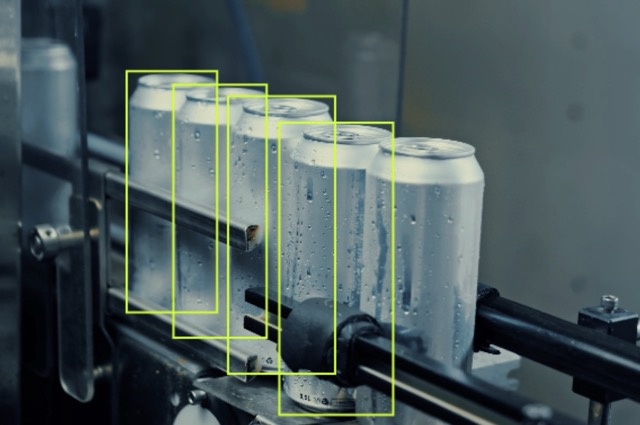

{'gemma-3n-E4B-it': '1', 'SmolVLM2': ' 4'}


In [26]:
#| code-fold: false
#| fig-cap: How many annotations are missing in the image? (an Annotation Understanding prompt from [VisionCheckup](https://visioncheckup.com/assessments/missing-annotation-in-image/))
#| label: fig-hfs-example
from gradio_client import Client, handle_file

prompt_im_url = 'https://visioncheckup.com/images/compressed/missing_annotation.jpeg'
model_zoo = {
    "gemma-3n-E4B-it": Client("huggingface-projects/gemma-3n-E4B-it", hf_token = os.environ["HUGGINGFACEHUB_API_TOKEN"]), # <1>
    "SmolVLM2": Client("Didier/Vision_Language_SmolVLM2")
}
results = {
    model_name: client.predict(
            		message={"text":"How many annotations are missing in the image? Return only a number.",
                             "files":[handle_file(prompt_im_url)]
                            },
            		# system_prompt="You are a helpful assistant.", # <2>
            		# max_new_tokens=700, # <3>
            		api_name="/chat",
            ) for model_name, client in model_zoo.items()}
display(Image(prompt_im_url))
print(results)

1. `hf_token` is optional here but if you are calling spaces that use *ZeroGPU* you will be limited to 5 inference minute per day without a PRO account token
2. commenting out `system_prompt` since it's not a parameters for the SmolVLM2 Space API
3. commenting out `max_new_tokens` since it's not a parameters for the SmolVLM2 Space API

# III. the `transformers` library
And finally for those cases where the models are neither supported by inference provider, nor availble in a space, we can load it up in the "traditional" sense using the [`transformers` library](https://huggingface.co/docs/transformers/model_doc/)

![[InternVL3](https://huggingface.co/collections/OpenGVLab/internvl3-67f7f690be79c2fe9d74fe9d) performance on select vision benchmarks](https://cdn-uploads.huggingface.co/production/uploads/619507e7b74b6c591f794340/4GqLJBNhM2rUqS_4mawkk.png){style="float: right; margin: 10px;" width=350  .lightbox #fig-internvl3}

For example, the [InternVL3](https://huggingface.co/docs/transformers/model_doc/internvl#video-input) model supports Chat Completion on Video Inputs. It comes in a variety of model size (with Quantization) and fairly high score on various vision benchmarks. But the model is relatively new[^internvl3-note] and released by a small group of chinese researchers at [OpenGVLab](https://huggingface.co/OpenGVLab), so currently there's no inference provider support and no space demo exists. 

But that doesn't stop us from testing it out locally against one of the videos on [CameraBench](https://huggingface.co/datasets/syCen/CameraBench)[^hf-dataset-note] @vid-internvl. 
Here we are experimenting with a prompt to extract enough temporal and visual features for downstream classification task[^caption-prompt-note].

[^internvl3-note]: [released Apr 2025](https://huggingface.co/papers/2504.10479) and was "#1 Paper of the day"
[^hf-dataset-note]: there are lots of [video dataset](https://huggingface.co/datasets?modality=modality:video&library=library:datasets&sort=trending) on huggingface, this CameraBench was used to validate a Qwen2.5VL model fine tuned for camera motion understanding
[^caption-prompt-note]: a [June 2025 study](https://www.nature.com/articles/s41598-025-04384-8) found higher image classification accuracy when combining VLM & LLM and the [FlexCap model (March 2024)](https://arxiv.org/html/2403.12026v1) also propose a captioning first approach then second-stage reasoning task using a LLM. For more, see research notes [created in Khoj](https://app.khoj.dev/share/chat/vlm-prompts-for-image-and-video-classification-8c215b2c/) and [NotebookLM](https://notebooklm.google.com/notebook/a2910f38-7022-4a9f-a5ac-0039c9f47911)

In [19]:
#| code-fold: true
#| fig-cap: InternVL3 Demo Video Captioning
#| label: vid-internvl
%%time
from transformers import AutoProcessor, AutoModelForImageTextToText # <1>
import torch
from IPython.display import Video

torch_device = "mps" # <2>
model_checkpoint = "OpenGVLab/InternVL3-1B-hf"
processor = AutoProcessor.from_pretrained(model_checkpoint)
model = AutoModelForImageTextToText.from_pretrained(model_checkpoint, device_map=torch_device, torch_dtype=torch.bfloat16)

video_url = "https://huggingface.co/datasets/syCen/CameraBench/resolve/main/videos/-FGVJS3rT80.2.1.mp4"
caption_prompt = """
Describe the main subject(s) and the primary activity or event depicted in this video segment in detail. 
Focus on dynamic characteristics, temporal patterns, and visual attributes that would help distinguish this 
from similar actions, objects, or events for classification purposes. 
Provide a concise yet comprehensive caption that highlights key movements, states, interactions, and any significant changes 
in the scene or subjects over time. 
For example, include information about the subjects' appearance (color, shape, distinctive markings), 
their specific actions (e.g., running, grasping, turning), how they interact with other objects or people,
the sequence of events, and the evolving environment.

Caption:
"""
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "video",
                "url": video_url,
            },
            {"type": "text", "text": caption_prompt},
        ],
    }
]
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    num_frames = 8
    ).to(model.device, dtype=torch.bfloat16)

output = model.generate(**inputs, max_new_tokens=500)

decoded_output = processor.decode(output[0, inputs["input_ids"].shape[1] :], skip_special_tokens=True)

display(Video(video_url, width=500))
print( f'{model_checkpoint} output: {decoded_output}')

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


OpenGVLab/InternVL3-1B-hf output: The video begins with a view from inside a spacecraft, looking out towards Earth. The spacecraft's circular structure is prominently visible, with a large circular opening at the top. The Earth is seen in the background, with its blue oceans and scattered white clouds. The spacecraft's surface has a black and white striped pattern. As the video progresses, the spacecraft moves closer to the Earth, and the opening at the top of the structure becomes more visible. The spacecraft continues to ascend, and the opening gradually becomes more circular. The Earth remains in the background, and the spacecraft's surface continues to show the black and white striped pattern. The video concludes with the spacecraft nearing the Earth, with the opening at the top of the structure becoming more circular.
CPU times: user 7.36 s, sys: 19.1 s, total: 26.4 s
Wall time: 46.1 s


1. you will need to `pip install av` which is [PyAV](https://github.com/PyAV-Org/PyAV)
2. change this to `cpu` if you don't have a Apple Sillicon chip or `cuda` if you got one

## make your own Space
but since making the model run is so simple, why not make your own space so that the model can be hosted on HuggingFace's infrastructure for "free"[^hfs-note]?

For models with utility, it might make sense to just write the code once and then have it be always available in the "cloud". For example, our [SAM2 Space](https://huggingface.co/spaces/GF-John/sam2?view=api) provides Image and Video inference running on ZeroGPU[^zerogpu-note]. As a bonus, building gradio apps are actually [quite simple](https://huggingface.co/learn/llm-course/chapter9/2?fw=pt), the [docs](https://www.gradio.app/guides/quickstart) are well written, and there's even [an interface for loading any model or space directly](https://huggingface.co/learn/llm-course/chapter9/5?fw=pt#loading-models-from-the-hugging-face-hub) into the space you are trying to create. Talk about standing on shoulders of giants!

[^hfs-note]: spaces go to sleep after [48 hours of inactivity](https://huggingface.co/docs/hub/spaces-gpus#sleep-time) but you could easily set up some github action to ping it daily
[^zerogpu-note]: ZeroGPU are [H200 with 70GB of VRAM](https://huggingface.co/docs/hub/spaces-zerogpu#using-and-hosting-zerogpu-spaces), all users get 5 minutes of inference time per day and PROs get 25 minutes. And the quota is on inference, NOT for the space's uptime (which could practically be indefinite).

Others in the community have also found creative ways to use Spaces, for example:

* [Deploying a FastAPI app via Docker](https://huggingface.co/blog/HemanthSai7/deploy-applications-on-huggingface-spaces), like [this space](https://huggingface.co/spaces/hars1k1234/video-imagebind-embedding) that's basically an [ImageBind](https://imagebind.metademolab.com) Video Embedding [API](https://hars1k1234-video-imagebind-embedding.hf.space/docs)[^fastapi-note]
* [Deploying n8n on Huggingface Spaces](https://tomo.dev/en/posts/deploy-n8n-for-free-using-huggingface-space/) with [example code](https://github.com/OmarHalima/n8n-huggingface-space) and literally [lots of people doing it](https://huggingface.co/spaces?q=n8n)

But that's a topic for another day...

[^fastapi-note]: although the built in API and MCP server that comes with any gradio app kinda make this "hack" obsolete